In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, LSTM, Dense, Dropout,
                                     Bidirectional, SpatialDropout1D,
                                     BatchNormalization)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [3]:
from google.colab import files
uploaded = files.upload()

df = pd.read_csv('Marathi_DM_Proj.csv')

# Map to sentiment labels (NOT emotion)
df['label'] = df['label'].map({1: 'Positive', 0: 'Neutral', -1: 'Negative'})
df = df.dropna(subset=['label'])

print("Shape:", df.shape)
print("\nSentiment Distribution:")
print(df['label'].value_counts())
df.head()

Saving Marathi_DM_Proj.csv to Marathi_DM_Proj.csv
Shape: (1500, 2)

Sentiment Distribution:
label
Positive    500
Neutral     500
Negative    500
Name: count, dtype: int64


,tweet,label
0,कोरोना काळात आपले पंतप्रधान मा. नरेंद्र मोदी...,Positive
1,पुणे येथे राष्ट्रसेवा दल अभ्यासिका विभाग यां...,Positive
2,"पुणे येथील ""क्रांती ज्योती"" या कार्यक्रमात ज...",Neutral
3,आद्यक्रांतिकारक उमाजीराजे नाईक यांना जयंतीनि...,Positive
4,महाराष्ट्राचे मुख्यमंत्री म्हणून शपथ घेतल्या...,Positive


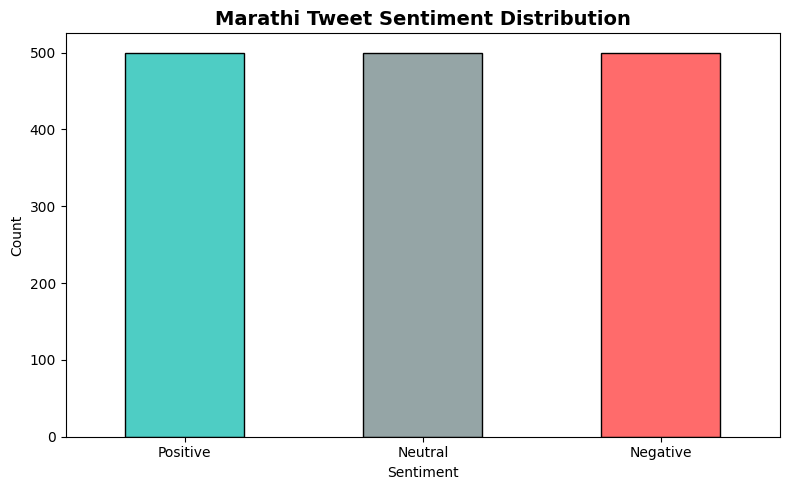


Text Length Statistics:
label
Negative    30.952
Neutral     24.424
Positive    24.062
Name: text_length, dtype: float64


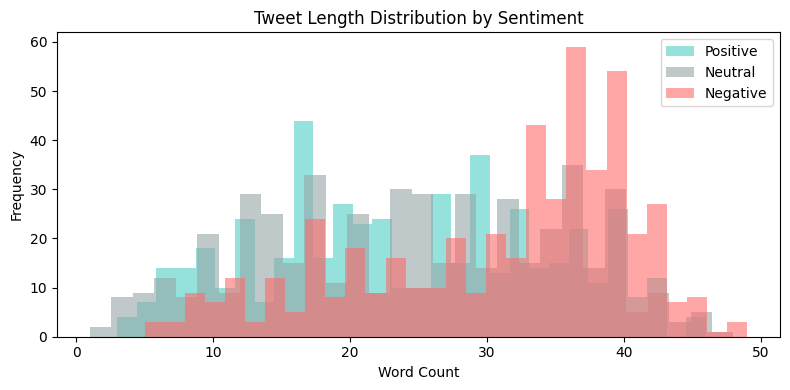

In [4]:
plt.figure(figsize=(8, 5))
colors = ['#4ECDC4', '#95A5A6', '#FF6B6B']
df['label'].value_counts().plot(kind='bar', color=colors, edgecolor='black')
plt.title('Marathi Tweet Sentiment Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df['text_length'] = df['tweet'].apply(lambda x: len(str(x).split()))
print("\nText Length Statistics:")
print(df.groupby('label')['text_length'].mean())

plt.figure(figsize=(8, 4))
for label, color in zip(['Positive', 'Neutral', 'Negative'],
                         ['#4ECDC4', '#95A5A6', '#FF6B6B']):
    subset = df[df['label'] == label]['text_length']
    plt.hist(subset, bins=30, alpha=0.6, label=label, color=color)
plt.title('Tweet Length Distribution by Sentiment')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
def clean_text(text):
    text = str(text)
    text = re.sub(r'http\S+|www\S+|pic\.twitter\S+', '', text)  # remove URLs
    text = re.sub(r'@\w+', '', text)                              # remove mentions
    text = re.sub(r'<.*?>', '', text)                             # remove HTML
    text = re.sub(r'fb\.me\S+', '', text)                        # remove fb links
    # Keep Devanagari (Marathi/Hindi) and basic word chars
    text = re.sub(r'[^\w\s\u0900-\u097F]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['cleaned_text'] = df['tweet'].apply(clean_text)

# Remove empty rows after cleaning
df = df[df['cleaned_text'].str.strip() != '']
df = df.reset_index(drop=True)

print("Rows after cleaning:", len(df))
print("\nOriginal:", df['tweet'].iloc[0][:100])
print("\nCleaned :", df['cleaned_text'].iloc[0][:100])

Rows after cleaning: 1500

Original:   कोरोना काळात आपले पंतप्रधान मा. नरेंद्र मोदीजी यांनी समाजातील सर्व घटकांना दिलासा देण्यासाठी आत्मन

Cleaned : कोरोना काळात आपले पंतप्रधान मा नरेंद्र मोदीजी यांनी समाजातील सर्व घटकांना दिलासा देण्यासाठी आत्मनिर्


In [6]:
label_encoder = LabelEncoder()
df['encoded_label'] = label_encoder.fit_transform(df['label'])

print("Sentiment Mapping:")
for i, cls in enumerate(label_encoder.classes_):
    print(f"  {cls} -> {i}")

NUM_CLASSES = len(label_encoder.classes_)
print(f"\nTotal Classes: {NUM_CLASSES}")

Sentiment Mapping:
  Negative -> 0
  Neutral -> 1
  Positive -> 2

Total Classes: 3


In [7]:
MAX_WORDS = 15000
MAX_LEN   = 50
EMBED_DIM = 64

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(df['cleaned_text'])

sequences = tokenizer.texts_to_sequences(df['cleaned_text'])
X = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')
y = df['encoded_label'].values

print("Vocabulary size:", len(tokenizer.word_index))
print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 12963
X shape: (1500, 50)
y shape: (1500,)


In [8]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Train : {X_train.shape[0]}")
print(f"Val   : {X_val.shape[0]}")
print(f"Test  : {X_test.shape[0]}")

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))
print("\nClass Weights:", class_weight_dict)

Train : 1050
Val   : 225
Test  : 225

Class Weights: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0)}


In [9]:
tf.keras.backend.clear_session()

def build_lstm_model(vocab_size, embed_dim, max_len, num_classes):
    model = Sequential([
        Embedding(input_dim=vocab_size, output_dim=embed_dim,
                  input_length=max_len),
        SpatialDropout1D(0.3),
        Bidirectional(LSTM(64, return_sequences=True,
                           dropout=0.3, recurrent_dropout=0.3)),
        Bidirectional(LSTM(32, dropout=0.3,
                           recurrent_dropout=0.3)),
        Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
        BatchNormalization(),
        Dropout(0.4),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        metrics=['accuracy']
    )
    return model

model = build_lstm_model(MAX_WORDS, EMBED_DIM, MAX_LEN, NUM_CLASSES)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [10]:
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

history = model.fit(
    X_train, y_train,
    epochs=60,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 40s 679ms/step - accuracy: 0.3657 - loss: 1.2048 - val_accuracy: 0.3333 - val_loss: 1.1573 - learning_rate: 0.0010
Epoch 2/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 34s 640ms/step - accuracy: 0.5029 - loss: 1.0576 - val_accuracy: 0.4756 - val_loss: 1.1428 - learning_rate: 0.0010
Epoch 3/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 21s 626ms/step - accuracy: 0.7686 - loss: 0.6463 - val_accuracy: 0.5378 - val_loss: 1.1078 - learning_rate: 0.0010
Epoch 4/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 21s 635ms/step - accuracy: 0.9219 - loss: 0.3169 - val_accuracy: 0.5511 - val_loss: 1.0586 - learning_rate: 0.0010
Epoch 5/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 21s 652ms/step - accuracy: 0.9619 - loss: 0.1851 - val_accuracy: 0.6044 - val_loss: 1.0167 - learning_rate: 0.0010
Epoch 6/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 40s 615ms/step - accuracy: 0.9810 - loss: 0.1248 - val_accuracy: 0.5778 - val_loss: 0.9789 - learning_rate: 0.0010
Epoch 7/60
33/33 ━━━━━━━━━━━━━━━━━━━━ 21s 649ms/step - accuracy: 0.9790 - loss: 0.

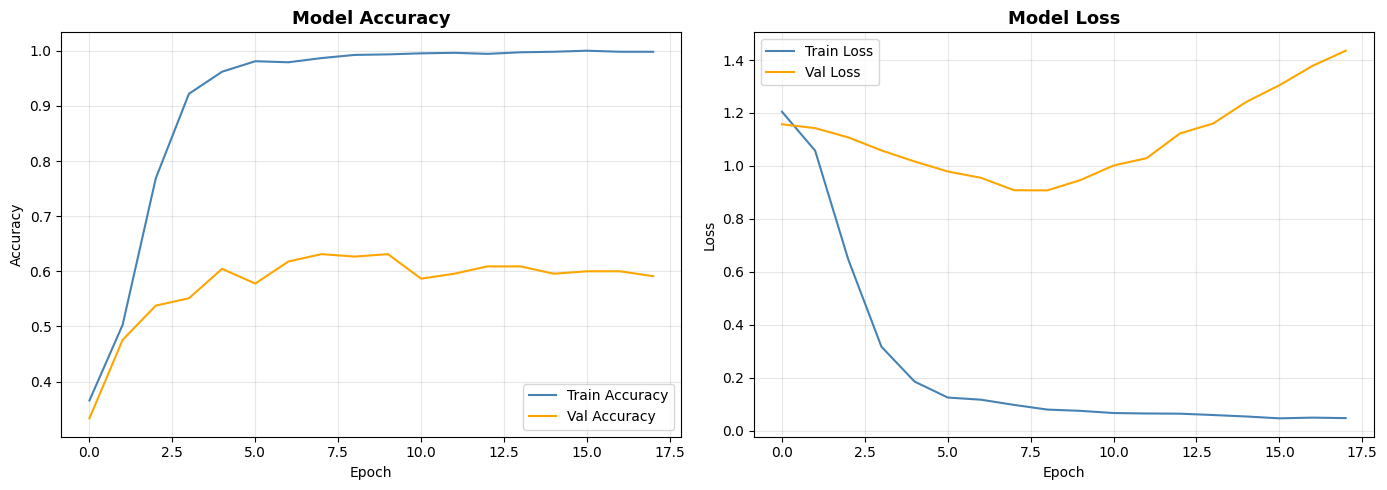

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],     label='Train Accuracy', color='steelblue')
axes[0].plot(history.history['val_accuracy'], label='Val Accuracy',   color='orange')
axes[0].set_title('Model Accuracy', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'],     label='Train Loss', color='steelblue')
axes[1].plot(history.history['val_loss'], label='Val Loss',   color='orange')
axes[1].set_title('Model Loss', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Test Accuracy : 0.7067
Test Loss     : 0.7929
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 277ms/step

Classification Report:
              precision    recall  f1-score   support

    Negative       0.79      0.76      0.78        75
     Neutral       0.63      0.68      0.65        75
    Positive       0.71      0.68      0.69        75

    accuracy                           0.71       225
   macro avg       0.71      0.71      0.71       225
weighted avg       0.71      0.71      0.71       225



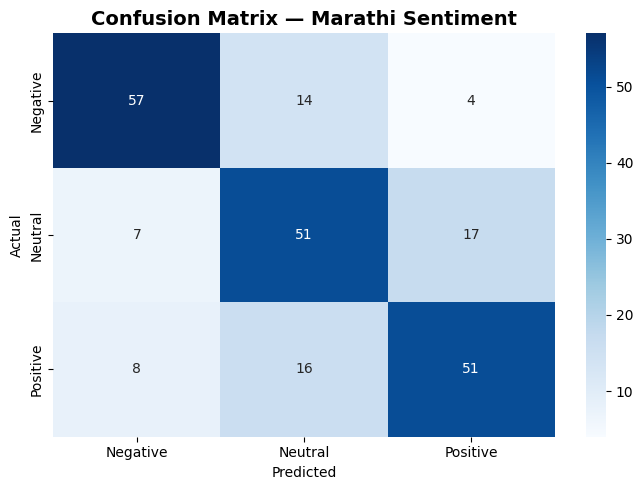

In [12]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy : {test_acc:.4f}")
print(f"Test Loss     : {test_loss:.4f}")

y_pred = np.argmax(model.predict(X_test), axis=1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred,
                             target_names=label_encoder.classes_))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix — Marathi Sentiment', fontsize=14, fontweight='bold')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [13]:
def predict_sentiment(text):
    cleaned = clean_text(text)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    pred = model.predict(padded, verbose=0)
    sentiment = label_encoder.inverse_transform([np.argmax(pred)])[0]
    confidence = np.max(pred) * 100

    print("\n" + "="*50)
    print(f"   Text      : {text[:60]}")
    print(f"   Sentiment : {sentiment}")
    print(f"   Confidence: {confidence:.2f}%")
    print("="*50 + "\n")

# Test with Marathi examples
predict_sentiment("मला खूप आनंद होतो आहे आज")
predict_sentiment("हे सरकार खूप वाईट आहे")
predict_sentiment("आज विधानसभेत चर्चा झाली")

print("\n Marathi Sentiment Analyzer")
print("   Enter Marathi tweets to analyze")
print("   Type 'quit' to exit\n")

while True:
    user_input = input("Enter Marathi tweet: ").strip()
    if not user_input:
        print(" Please enter some text.\n")
        continue
    if user_input.lower() == 'quit':
        print("Exiting.")
        break
    predict_sentiment(user_input)


   Text      : मला खूप आनंद होतो आहे आज
   Sentiment : Positive
   Confidence: 71.40%


   Text      : हे सरकार खूप वाईट आहे
   Sentiment : Positive
   Confidence: 63.60%


   Text      : आज विधानसभेत चर्चा झाली
   Sentiment : Neutral
   Confidence: 75.36%


 Marathi Sentiment Analyzer
   Enter Marathi tweets to analyze
   Type 'quit' to exit

Enter Marathi tweet: quit
Exiting.


In [14]:
import pickle

model.save('marathi_sentiment_lstm.keras')

with open('tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

from google.colab import files
files.download('marathi_sentiment_lstm.keras')
files.download('tokenizer.pkl')
files.download('label_encoder.pkl')

print(" Model saved!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 Model saved!
